# Marketing A/B Test Analysis

## 分析目的

広告表示がユーザーのコンバージョン率に与える効果を検証する。

広告を表示した `ad` 群と、PSA（Public Service Announcement）を表示した `psa` 群のコンバージョン率を比較し、広告表示によってコンバージョン率が統計的に有意に向上しているかを検証する。

## 1. データの読み込み・前処理

分析に使用するデータを読み込み、データの内容を確認する。

In [1]:
import pandas as pd

df = pd.read_csv("marketing_AB.csv")

In [2]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [3]:
df = df.drop(columns=["Unnamed: 0"])

In [4]:
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


## 2. データの確認

データ件数、カラム数、データ型、欠損値、ユーザーIDの重複を確認する。

In [5]:
df.shape

(588101, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user id        588101 non-null  int64 
 1   test group     588101 non-null  object
 2   converted      588101 non-null  bool  
 3   total ads      588101 non-null  int64 
 4   most ads day   588101 non-null  object
 5   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(3), object(2)
memory usage: 23.0+ MB


In [7]:
df["user id"].duplicated().sum()

np.int64(0)

## 3. A/Bグループの比較

各グループのサンプル数とコンバージョン率を確認する。

In [8]:
df["test group"].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [9]:
df.groupby("test group")["converted"].mean()

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

In [10]:
ad_converted = df[df["test group"] == "ad"]["converted"].sum()

In [11]:
psa_converted = df[df["test group"] == "psa"]["converted"].sum()

In [12]:
ad_total = len(df[df["test group"] == "ad"])

In [13]:
psa_total = len(df[df["test group"] == "psa"])

## 4. 仮説検定

ad群のコンバージョン率がpsa群より統計的に有意に高いかを、2群の比率のz検定を用いて検証する。

- 帰無仮説 H₀：`ad` 群と `psa` 群のコンバージョン率に差はない
- 対立仮説 H₁：`ad` 群のコンバージョン率は `psa` 群より高い
- 有意水準：5%

In [14]:
from statsmodels.stats.proportion import proportions_ztest

In [15]:
count = [ad_converted, psa_converted]
nobs = [ad_total, psa_total]

In [16]:
z_stat, p_value = proportions_ztest(
    count,
    nobs,
    alternative="larger"
)

print("z統計量:", z_stat)
print("p値:", p_value)

z統計量: 7.3700781265454145
p値: 8.526403580779857e-14


### 95%信頼区間

コンバージョン率の差がどの程度の範囲にあると考えられるかを確認するため、`ad` 群と `psa` 群のコンバージョン率の差について95%信頼区間を算出する。

In [17]:
from statsmodels.stats.proportion import confint_proportions_2indep

In [18]:
ci_low, ci_high = confint_proportions_2indep(
    ad_converted,
    ad_total,
    psa_converted,
    psa_total,
    method="wald"
)

print("95%信頼区間:", ci_low, ci_high)

95%信頼区間: 0.005950932431611005 0.00943397395279203


## 5. コンバージョン率の可視化

`ad` 群と `psa` 群のコンバージョン率を棒グラフで比較する。

In [19]:
import matplotlib.pyplot as plt

In [20]:
conversion_rates = df.groupby("test group")["converted"].mean()

In [21]:
from matplotlib.ticker import PercentFormatter

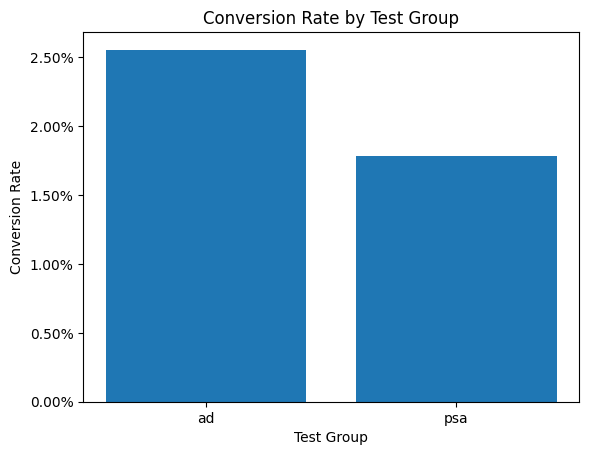

In [22]:
plt.bar(conversion_rates.index, conversion_rates.values)

plt.xlabel("Test Group")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Test Group")

plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.show()

## 6. 分析結果・考察

- `ad` 群のコンバージョン率は約2.55%、`psa` 群は約1.79%であり、`ad` 群が約0.77ポイント高かった。
- 相対的には、`ad` 群のコンバージョン率は `psa` 群より約42.5%高かった。
- 2群の比率のz検定の結果、p値は有意水準5%を大きく下回ったため、帰無仮説を棄却した。
- コンバージョン率の差の95%信頼区間は約0.60〜0.94ポイントであり、0を含まなかった。

以上から、`ad` 群のコンバージョン率は `psa` 群より統計的に有意に高いと判断した。

## 7. ビジネス上の提案・分析上の限界

### ビジネス上の提案

分析の結果、広告を表示したad群では、psa群よりコンバージョン率が高い結果となった。統計的にも有意な差が確認されたことから、広告表示によってコンバージョン率が改善する可能性があると考えた。

一方、コンバージョン率の絶対差は約0.77ポイントであるため、広告施策を実施・拡大するかどうかは、広告費や商品単価、利益率などを考慮して総合的に判断する必要がある。

今後は広告費や商品単価などのデータを追加し、広告による増分利益や費用対効果を検証する。

### 分析上の限界

- `ad` 群564,577人、`psa` 群23,524人とサンプルサイズに大きな偏りがあるため、実務ではグループの割り当て方法や実験設計を確認する必要がある。
- 本データには広告費、商品単価、利益などの情報が含まれていないため、広告の費用対効果までは判断できない。